# Task 3 - Natural Language Processing (NLP) - Sentiment Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

df = pd.read_csv(r"C:\Users\umani\Downloads\Sentiment dataset.csv")
df.head()

### For the file name
os.listdir() was used to check available files and locate the dataset.

In [3]:
import os
print(os.listdir())

['.anaconda', '.conda', '.condarc', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ms-ad', '.spss', '.vscode', 'anaconda3', 'AppData', 'Application Data', 'cleaned_churn_dataset.csv', 'Contacts', 'Cookies', 'Day 10.ipynb', 'DAY 11.ipynb', 'Day 12 challange.ipynb', 'Day 13 challange.ipynb', 'Day 14 challange.ipynb', 'DAY 15 challange.ipynb', 'DAY 2 Challange.ipynb', 'DAY 3 Challange.ipynb', 'DAY 4 Challange.ipynb', 'DAY 5 Challange.ipynb', 'DAY 6 Challange .ipynb', 'DAY 7 Challange.ipynb', 'Day 8 Challange.ipynb', 'DAY 9 Challange.ipynb', 'Desktop', 'Documents', 'Downloads', 'edb_languagepack_4.exe', 'edb_languagepack_4.exe-20240818131313', 'edb_mtk.exe', 'edb_npgsql.exe', 'edb_pem_agent.exe', 'edb_pem_agent_8.exe', 'edb_pem_server.exe', 'edb_pem_server_8.exe', 'edb_pem_sqlprofiler_pg16.exe', 'edb_pgagent_pg16.exe', 'edb_pgbouncer.exe', 'edb_pgjdbc.exe', 'edb_psqlodbc.exe', 'edb_psqlodbc.exe-20240818140439', 'edb_sqlprotect_pg16.exe', 'edb_xdb_62.exe', 'edb

## Install and Import Required Packages
NLTK, TextBlob, and WordCloud were installed and imported for text processing and sentiment analysis.

In [4]:
!pip install nltk textblob wordcloud

Defaulting to user installation because normal site-packages is not writeable


## Download NLTK Resources
Required NLTK resources like punkt and stopwords were downloaded for preprocessing.

In [5]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from wordcloud import WordCloud

In [6]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\umani\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\umani\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

## Preprocess Text
Text was cleaned by converting to lowercase, removing stopwords, tokenizing, and applying stemming

In [7]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    text = str(text).lower()

    words = word_tokenize(text)

    words = [word for word in words if word.isalpha()]

    words = [word for word in words if word not in stop_words]

    words = [stemmer.stem(word) for word in words]

    return " ".join(words)

df['Processed_Text'] = df['Text'].apply(preprocess)

df[['Text','Processed_Text']].head()

,Text,Processed_Text
0,Enjoying a beautiful day at the park! ...,enjoy beauti day park
1,Traffic was terrible this morning. ...,traffic terribl morn
2,Just finished an amazing workout! 💪 ...,finish amaz workout
3,Excited about the upcoming weekend getaway! ...,excit upcom weekend getaway
4,Trying out a new recipe for dinner tonight. ...,tri new recip dinner tonight


## Sentiment Analysis Using TextBlob
TextBlob was used to classify text into Positive, Negative, or Neutral based on polarity.

In [8]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['Predicted_Sentiment'] = df['Processed_Text'].apply(get_sentiment)

df[['Processed_Text','Predicted_Sentiment']].head()

,Processed_Text,Predicted_Sentiment
0,enjoy beauti day park,Positive
1,traffic terribl morn,Neutral
2,finish amaz workout,Neutral
3,excit upcom weekend getaway,Neutral
4,tri new recip dinner tonight,Positive


## Visualize Sentiment Distribution
A bar chart showed sentiment distribution, and a word cloud displayed frequent words

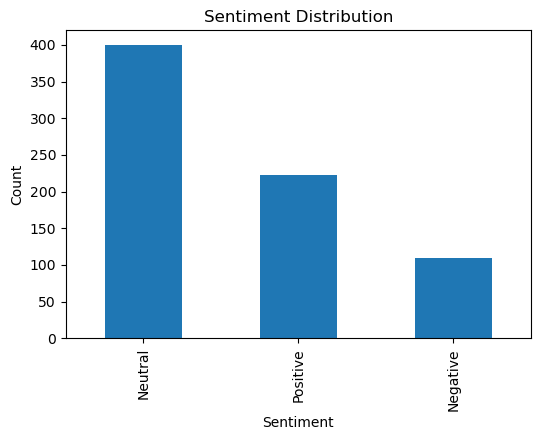

In [9]:
sentiment_counts = df['Predicted_Sentiment'].value_counts()

plt.figure(figsize=(6,4))
sentiment_counts.plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

## Generate Word Cloud
A word cloud was created to show the most frequent words in the processed text.

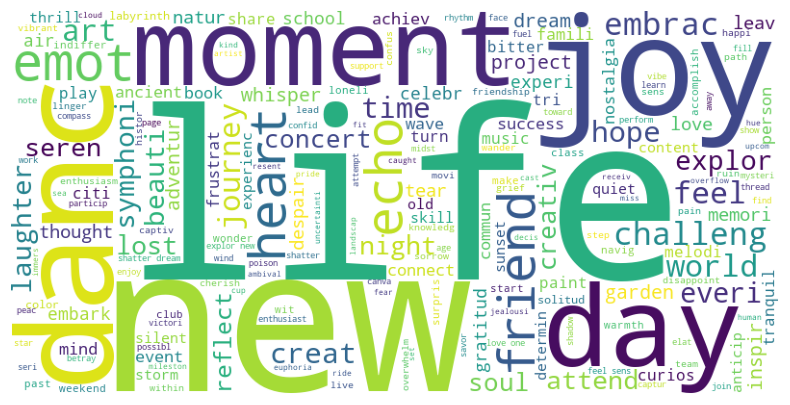

In [10]:
text = " ".join(df['Processed_Text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()